<a href="https://colab.research.google.com/github/VaibhaviAnnam/land-use-classification-urban-heat-analysis/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================
# MUMBAI BMC LULC ANALYSIS
# Python graphs
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# =============================================
# DATA FROM GEE CONSOLE
# =============================================

years = [2000, 2005, 2010, 2015, 2020, 2025]

# Area Statistics (km²) — from your latest GEE run
area_data = {
    'Year':       [2000,   2005,   2010,   2015,   2020,   2025],
    'Built_up':   [141.19, 143.74, 140.05, 192.02, 192.65, 194.22],
    'Dense_Veg':  [60.98,   57.02,  59.91,  44.06, 36.20,  32.10],
    'Sparse_Veg': [31.59,  85.76,  93.84,  88.20,  96.63,  80.52],
    'Water':      [105.96, 92.24,  81.17, 74.80,  71.09,  81.09],
    'Open_Land':  [178.36, 118.32, 103.09, 48.99,  31.51,  30.16]
}

In [ ]:
#NDVI Mean — from GEE console
ndvi_mean = [0.0813, 0.1039, 0.1076, 0.1282, 0.1351, 0.1257]

# LST Mean (°C) — from GEE console
lst_mean  = [38.62, 34.76, 34.42, 34.45, 36.31, 37.79]
lst_max   = [53.70, 51.84, 51.79, 46.57, 51.21, 51.58]
lst_min   = [25.96, 22.42, 23.77, 24.58, 26.53, 27.11]

In [ ]:
# Create DataFrame
df = pd.DataFrame(area_data)
df['NDVI_mean'] = ndvi_mean
df['LST_mean']  = lst_mean
df['LST_max']   = lst_max
df['LST_min']   = lst_min
df['Total']     = (df['Built_up'] + df['Dense_Veg'] +
                   df['Sparse_Veg'] + df['Water'] + df['Open_Land'])


In [ ]:
# Colors matching GEE map exactly
colors = {
    'Built_up':   '#e31a1c',
    'Dense_Veg':  '#1a6600',
    'Sparse_Veg': '#76b349',
    'Water':      '#0000ff',
    'Open_Land':  '#d3a04b'
}
labels = {
    'Built_up':   'Built-up Area',
    'Dense_Veg':  'Dense Vegetation',
    'Sparse_Veg': 'Sparse Vegetation',
    'Water':      'Water Body',
    'Open_Land':  'Open Land'
}

print("=== DATA LOADED ===")
print(df[['Year','Built_up','Dense_Veg',
          'Sparse_Veg','Water','Open_Land']].to_string(index=False))


=== DATA LOADED ===
 Year  Built_up  Dense_Veg  Sparse_Veg  Water  Open_Land
 2000    141.19      60.98       31.59 105.96     178.36
 2005    143.74      57.02       85.76  92.24     118.32
 2010    140.05      59.91       93.84  81.17     103.09
 2015    192.02      44.06       88.20  74.80      48.99
 2020    192.65      36.20       96.63  71.09      31.51
 2025    194.22      32.10       80.52  81.09      30.16


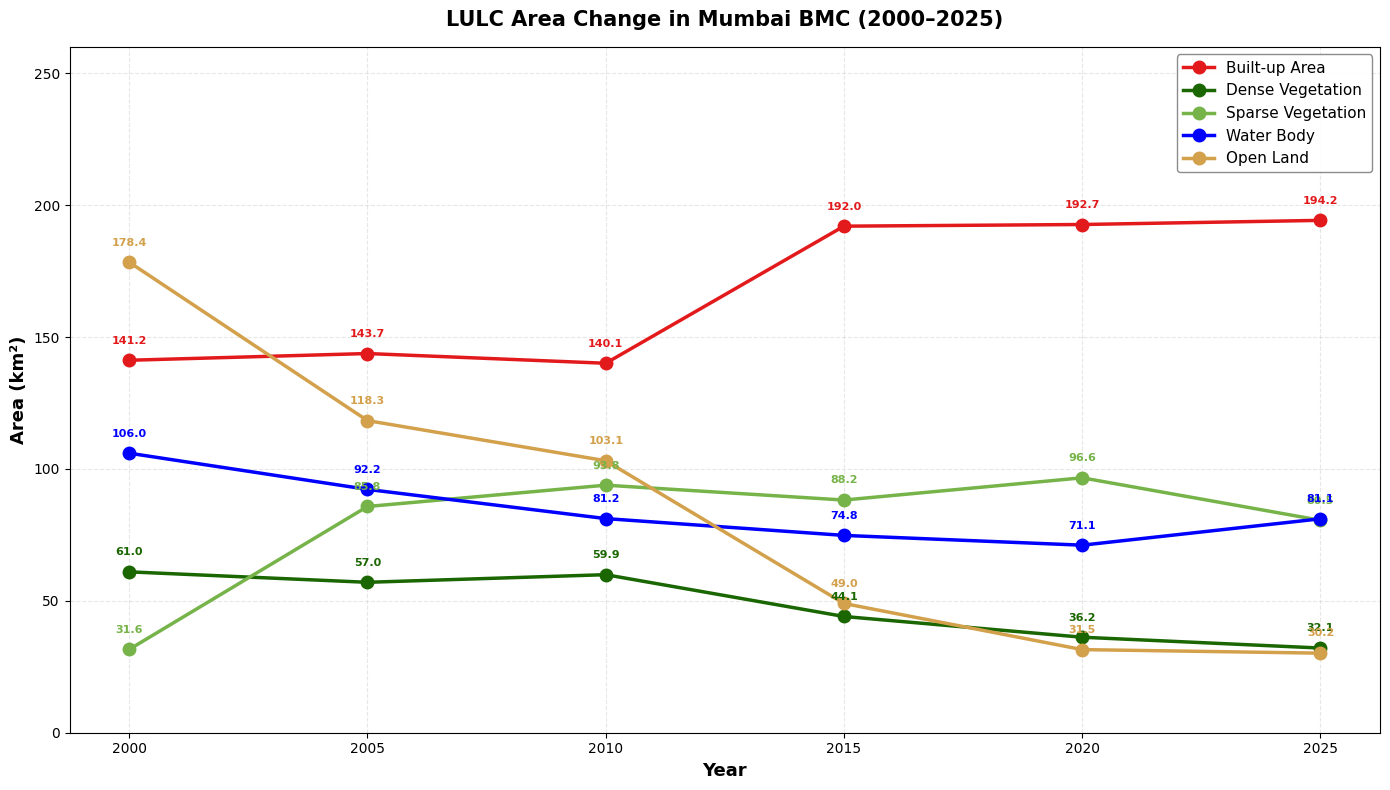

In [ ]:
# =============================================
# GRAPH 1 — LULC AREA CHANGE LINE GRAPH
# =============================================

fig, ax = plt.subplots(figsize=(14, 8))

for col, color in colors.items():
    ax.plot(years, df[col],
            color=color, linewidth=2.5,
            marker='o', markersize=9,
            label=labels[col])
    for x, y in zip(years, df[col]):
        ax.annotate(f'{y:.1f}',
                   xy=(x, y),
                   textcoords='offset points',
                   xytext=(0, 12),
                   ha='center', fontsize=8,
                   color=color, fontweight='bold')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Area (km²)', fontsize=13, fontweight='bold')
ax.set_title('LULC Area Change in Mumbai BMC (2000–2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11,
          framealpha=0.9, edgecolor='gray')
ax.set_xticks(years)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 260)
plt.tight_layout()
plt.savefig('Graph1_LULC_Area_Change.png', dpi=300, bbox_inches='tight')
plt.show()

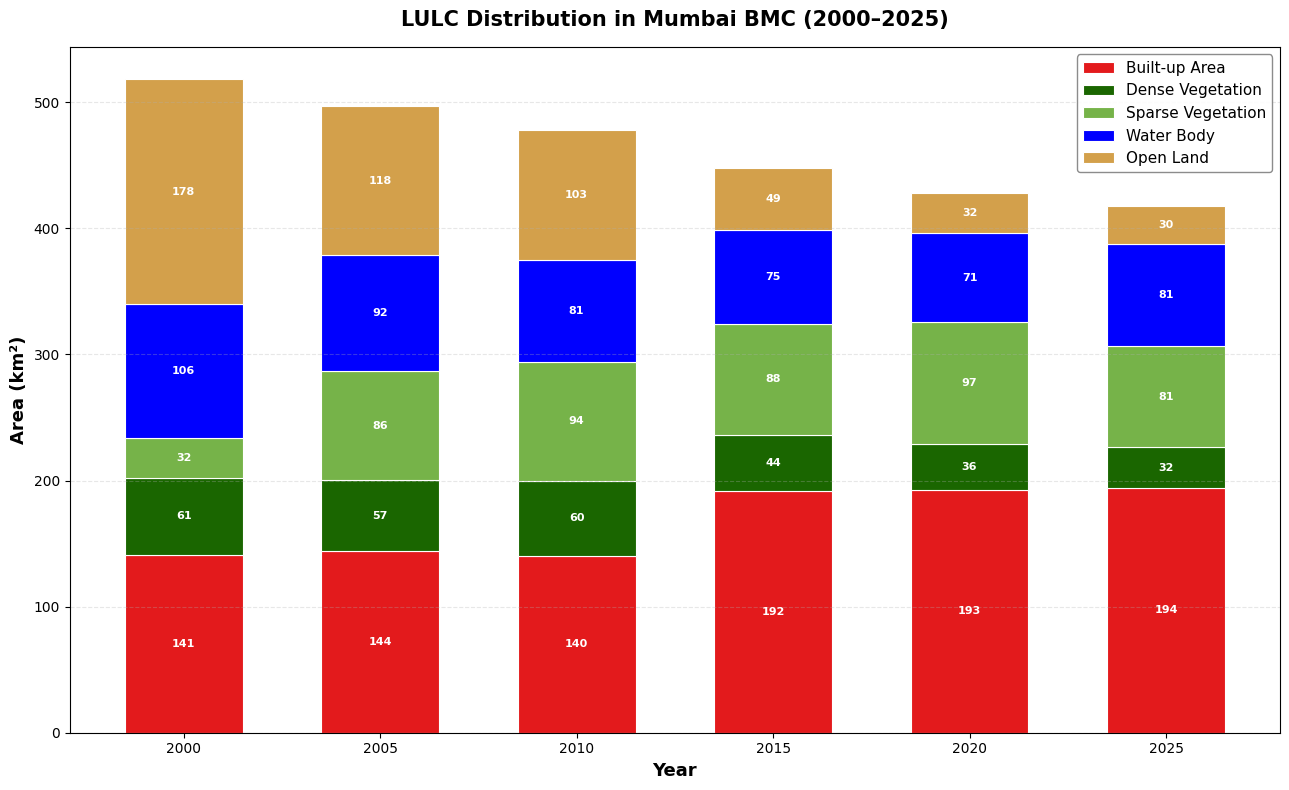

In [ ]:
# =============================================
# GRAPH 2 — STACKED BAR CHART
# =============================================

fig, ax = plt.subplots(figsize=(13, 8))

bar_width = 3
bottom = np.zeros(len(years))

for col, color in colors.items():
    values = df[col].values
    bars = ax.bar(years, values, bar_width,
                  bottom=bottom,
                  color=color,
                  label=labels[col],
                  edgecolor='white',
                  linewidth=0.8)
    # Add value labels inside bars
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val > 8:
            ax.text(years[i], bot + val/2,
                   f'{val:.0f}',
                   ha='center', va='center',
                   fontsize=8, color='white',
                   fontweight='bold')
    bottom += values

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Area (km²)', fontsize=13, fontweight='bold')
ax.set_title('LULC Distribution in Mumbai BMC (2000–2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11,
          framealpha=0.9, edgecolor='gray')
ax.set_xticks(years)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig('Graph2_Stacked_Bar.png', dpi=300, bbox_inches='tight')
plt.show()

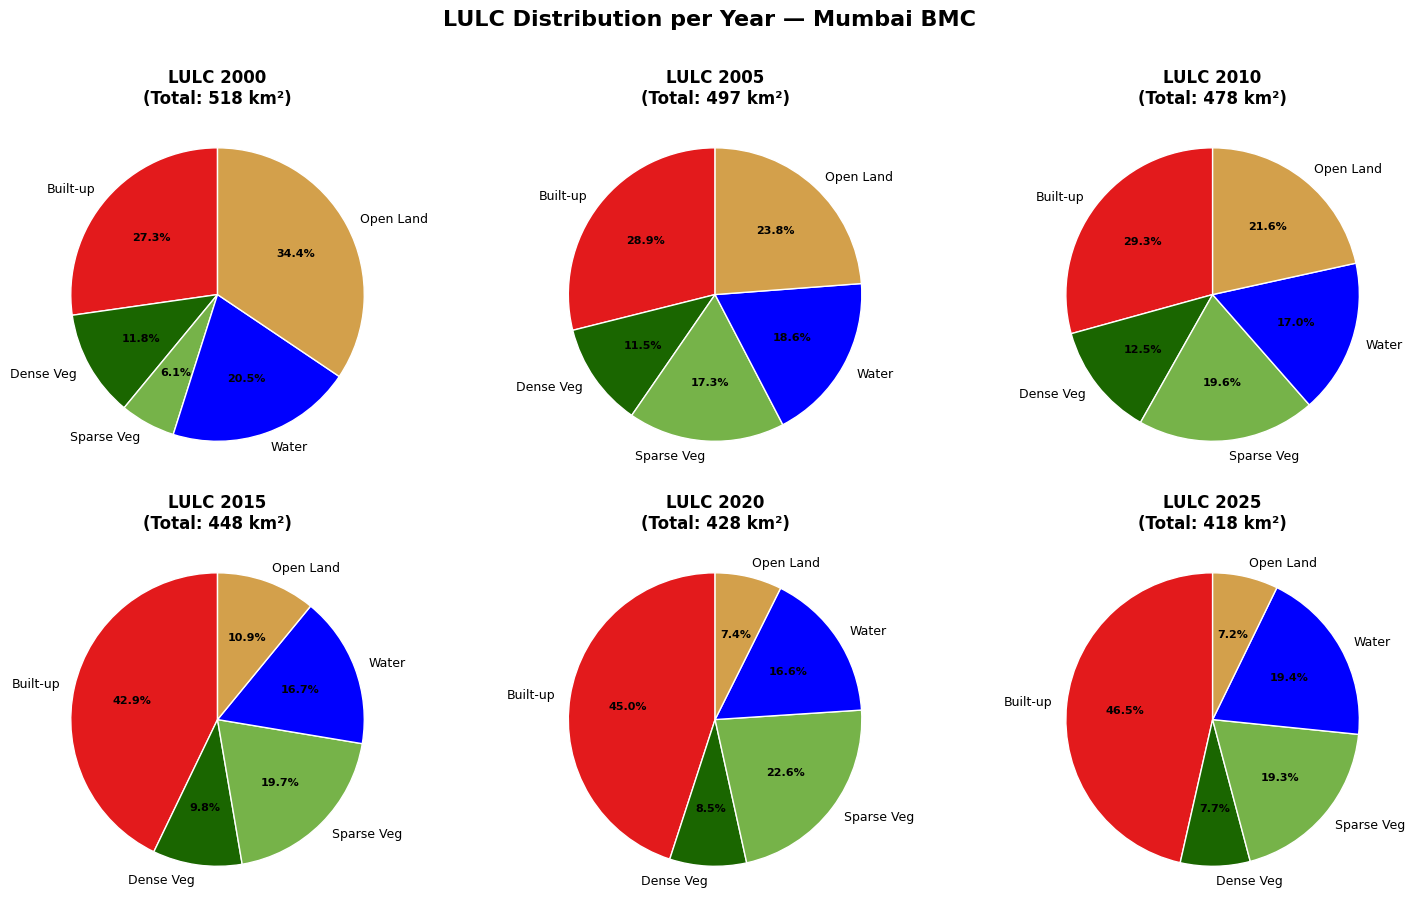

In [ ]:
# =============================================
# GRAPH 3 — PIE CHARTS (6 years)
# =============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

pie_colors = ['#e31a1c','#1a6600','#76b349','#0000ff','#d3a04b']
pie_labels = ['Built-up','Dense Veg','Sparse Veg','Water','Open Land']

for i, year in enumerate(years):
    row = df[df['Year'] == year].iloc[0]
    values = [row['Built_up'], row['Dense_Veg'],
              row['Sparse_Veg'], row['Water'], row['Open_Land']]
    total  = sum(values)

    wedges, texts, autotexts = axes[i].pie(
        values,
        labels=pie_labels,
        colors=pie_colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')

    axes[i].set_title(f'LULC {year}\n(Total: {total:.0f} km²)',
                     fontsize=12, fontweight='bold')

plt.suptitle('LULC Distribution per Year — Mumbai BMC',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Graph3_Pie_Charts.png', dpi=300, bbox_inches='tight')
plt.show()

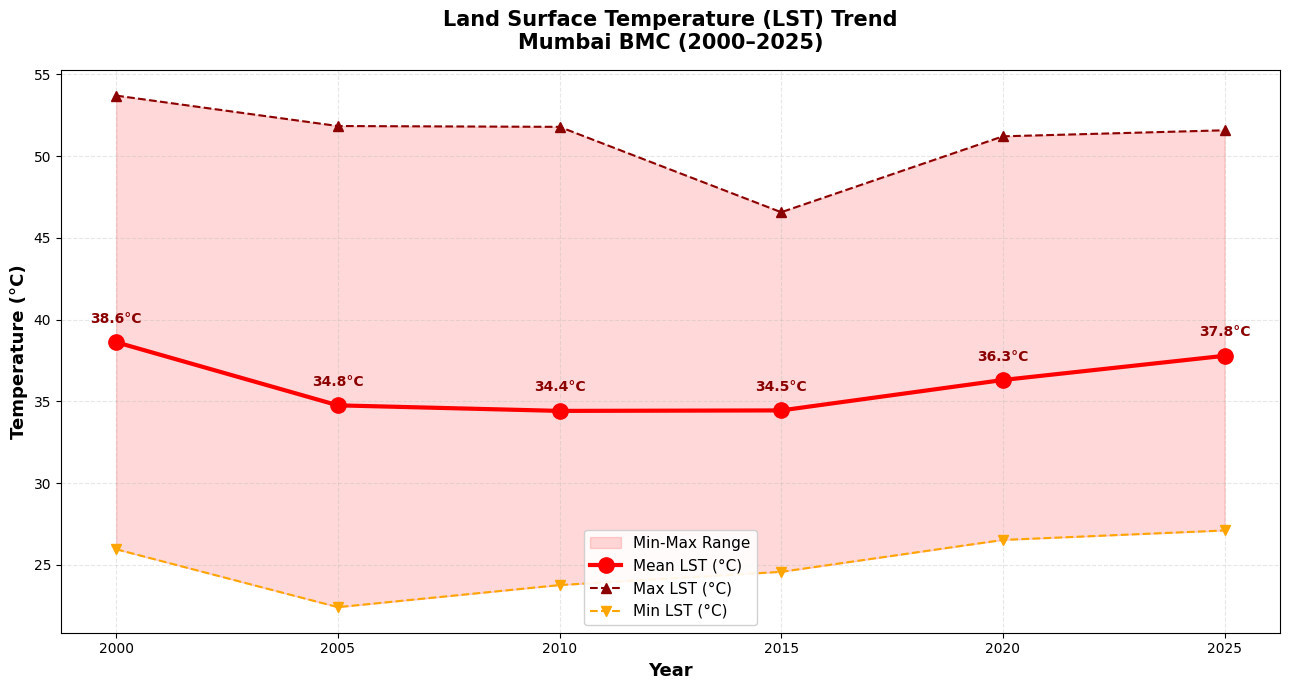

In [ ]:
# =============================================
# GRAPH 4 — LST TREND
# =============================================

fig, ax = plt.subplots(figsize=(13, 7))

ax.fill_between(years, lst_min, lst_max,
                alpha=0.15, color='red',
                label='Min-Max Range')
ax.plot(years, lst_mean,
        color='red', linewidth=3,
        marker='o', markersize=11,
        label='Mean LST (°C)', zorder=5)
ax.plot(years, lst_max,
        color='darkred', linewidth=1.5,
        linestyle='--', marker='^',
        markersize=7, label='Max LST (°C)')
ax.plot(years, lst_min,
        color='orange', linewidth=1.5,
        linestyle='--', marker='v',
        markersize=7, label='Min LST (°C)')

for x, y in zip(years, lst_mean):
    ax.annotate(f'{y:.1f}°C',
               xy=(x, y),
               textcoords='offset points',
               xytext=(0, 14),
               ha='center', fontsize=10,
               fontweight='bold', color='darkred')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax.set_title('Land Surface Temperature (LST) Trend\nMumbai BMC (2000–2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_xticks(years)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Graph4_LST_Trend.png', dpi=300, bbox_inches='tight')
plt.show()


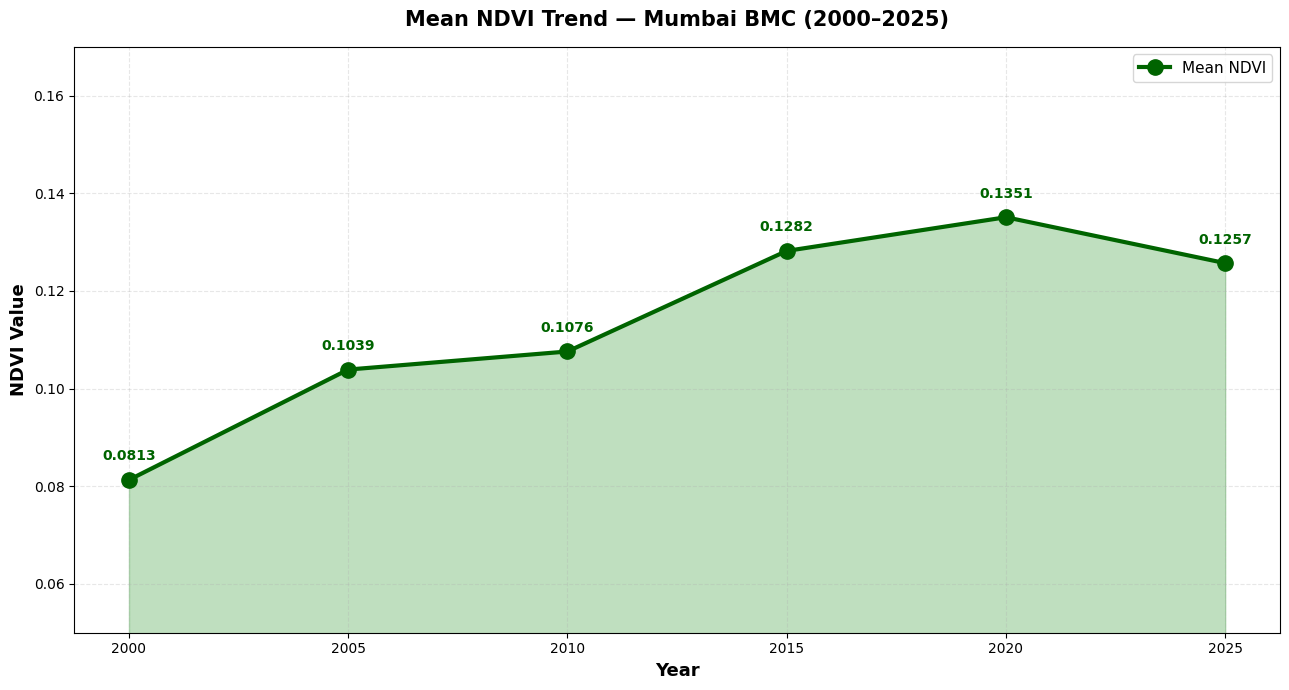

In [ ]:
# =============================================
# GRAPH 5 — NDVI TREND
# =============================================

fig, ax = plt.subplots(figsize=(13, 7))

ax.fill_between(years, ndvi_mean,
                alpha=0.25, color='green')
ax.plot(years, ndvi_mean,
        color='darkgreen', linewidth=3,
        marker='o', markersize=11,
        label='Mean NDVI')

for x, y in zip(years, ndvi_mean):
    ax.annotate(f'{y:.4f}',
               xy=(x, y),
               textcoords='offset points',
               xytext=(0, 14),
               ha='center', fontsize=10,
               color='darkgreen', fontweight='bold')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('NDVI Value', fontsize=13, fontweight='bold')
ax.set_title('Mean NDVI Trend — Mumbai BMC (2000–2025)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_xticks(years)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0.05, 0.17)
plt.tight_layout()
plt.savefig('Graph5_NDVI_Trend.png', dpi=300, bbox_inches='tight')
plt.show()



=== 2030 PREDICTION ===
Built_up        → 2030: 213.70 km²  (R²=0.777)
Dense_Veg       → 2030:  26.11 km²  (R²=0.887)
Sparse_Veg      → 2030: 106.59 km²  (R²=0.362)
Water           → 2030:  64.97 km²  (R²=0.659)
Open_Land       → 2030:   0.00 km²  (R²=0.919)

LST 2030 Prediction:  36.11 °C
NDVI 2030 Prediction: 0.1473


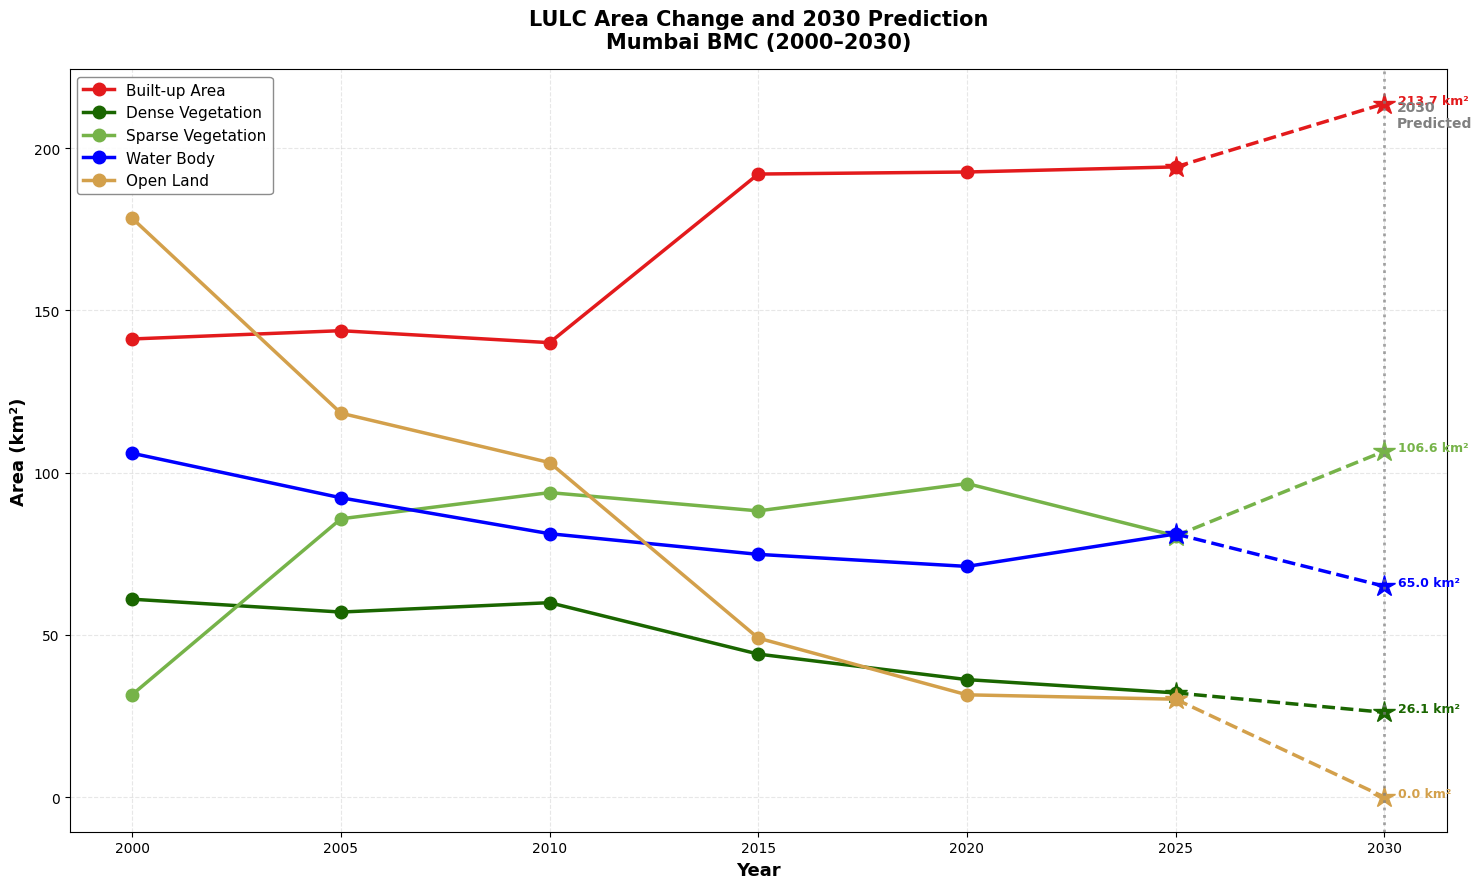

In [ ]:
# =============================================
# GRAPH 7 — 2030 PREDICTION
# STEP 10 — Linear Regression
# =============================================

print("\n=== 2030 PREDICTION ===")

years_arr = np.array(years).reshape(-1, 1)
predict_year = np.array([[2030]])
all_years = years + [2030]

predictions = {}
classes = ['Built_up','Dense_Veg','Sparse_Veg','Water','Open_Land']

for cls in classes:
    model = LinearRegression()
    model.fit(years_arr, df[cls].values)
    pred  = model.predict(predict_year)[0]
    r2    = model.score(years_arr, df[cls].values)
    predictions[cls] = max(0, round(pred, 2))
    print(f"{cls:15} → 2030: {predictions[cls]:6.2f} km²  (R²={r2:.3f})")

# LST prediction
lst_model = LinearRegression()
lst_model.fit(years_arr, np.array(lst_mean))
lst_2030  = lst_model.predict(predict_year)[0]
print(f"\nLST 2030 Prediction:  {lst_2030:.2f} °C")

# NDVI prediction
ndvi_model = LinearRegression()
ndvi_model.fit(years_arr, np.array(ndvi_mean))
ndvi_2030  = ndvi_model.predict(predict_year)[0]
print(f"NDVI 2030 Prediction: {ndvi_2030:.4f}")

# Draw Graph 7
fig, ax = plt.subplots(figsize=(15, 9))

for col, color in colors.items():
    historical = list(df[col].values)
    predicted  = predictions[col]

    # Historical line — solid
    ax.plot(years, historical,
            color=color, linewidth=2.5,
            marker='o', markersize=9,
            label=labels[col])

    # Prediction line — dotted
    ax.plot([2025, 2030],
            [historical[-1], predicted],
            color=color, linewidth=2.5,
            linestyle='--',
            marker='*', markersize=16)

    # Prediction value label
    ax.annotate(f'{predicted:.1f} km²',
               xy=(2030, predicted),
               textcoords='offset points',
               xytext=(10, 0),
               ha='left', fontsize=9,
               color=color, fontweight='bold')

# Vertical line at 2030
ax.axvline(x=2030, color='gray',
           linestyle=':', linewidth=2,
           alpha=0.7)
ax.text(2030.3, ax.get_ylim()[1]*0.92,
        '2030\nPredicted',
        fontsize=10, color='gray',
        fontweight='bold')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Area (km²)', fontsize=13, fontweight='bold')
ax.set_title('LULC Area Change and 2030 Prediction\nMumbai BMC (2000–2030)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11,
          framealpha=0.9, edgecolor='gray')
ax.set_xticks(all_years)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Graph7_Prediction_2030.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================
# CORRELATION GRAPHS — Like Reference Paper
# Pixel level NDVI/NDBI vs LST
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# =============================================
# LOAD CSV FILES
# =============================================

base_path = '/content/drive/MyDrive/LULC_Mumbai/'

years = [2000, 2005, 2010, 2015, 2020, 2025]
data  = {}

for year in years:
    try:
        df = pd.read_csv(f'{base_path}Pixel_Sample_{year}.csv')
        df = df.dropna()
        data[year] = df
        print(f'{year}: {len(df)} pixels loaded')
        print(f'  Columns: {list(df.columns)}')
    except:
        print(f'{year}: File not found')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2000: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']
2005: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']
2010: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']
2015: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']
2020: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']
2025: 2000 pixels loaded
  Columns: ['system:index', 'LST', 'NDBI', 'NDVI', 'NDWI', '.geo']


In [ ]:
# =============================================
# HELPER FUNCTION — Get column names
# =============================================

def get_col(df, keyword):
    cols = [c for c in df.columns if keyword.upper() in c.upper()]
    return cols[0] if cols else None

def clean_data(x, y):
    mask = (
        np.isfinite(x) & np.isfinite(y) &
        (y > 15) & (y < 60) &
        (x > -1) & (x < 1)
    )
    return x[mask], y[mask]

2000 NDVI-LST: r=-0.211 | R²=0.045 | p=0.0000
2005 NDVI-LST: r=-0.313 | R²=0.098 | p=0.0000
2010 NDVI-LST: r=-0.417 | R²=0.174 | p=0.0000
2015 NDVI-LST: r=-0.411 | R²=0.169 | p=0.0000
2020 NDVI-LST: r=-0.357 | R²=0.127 | p=0.0000
2025 NDVI-LST: r=-0.337 | R²=0.114 | p=0.0000


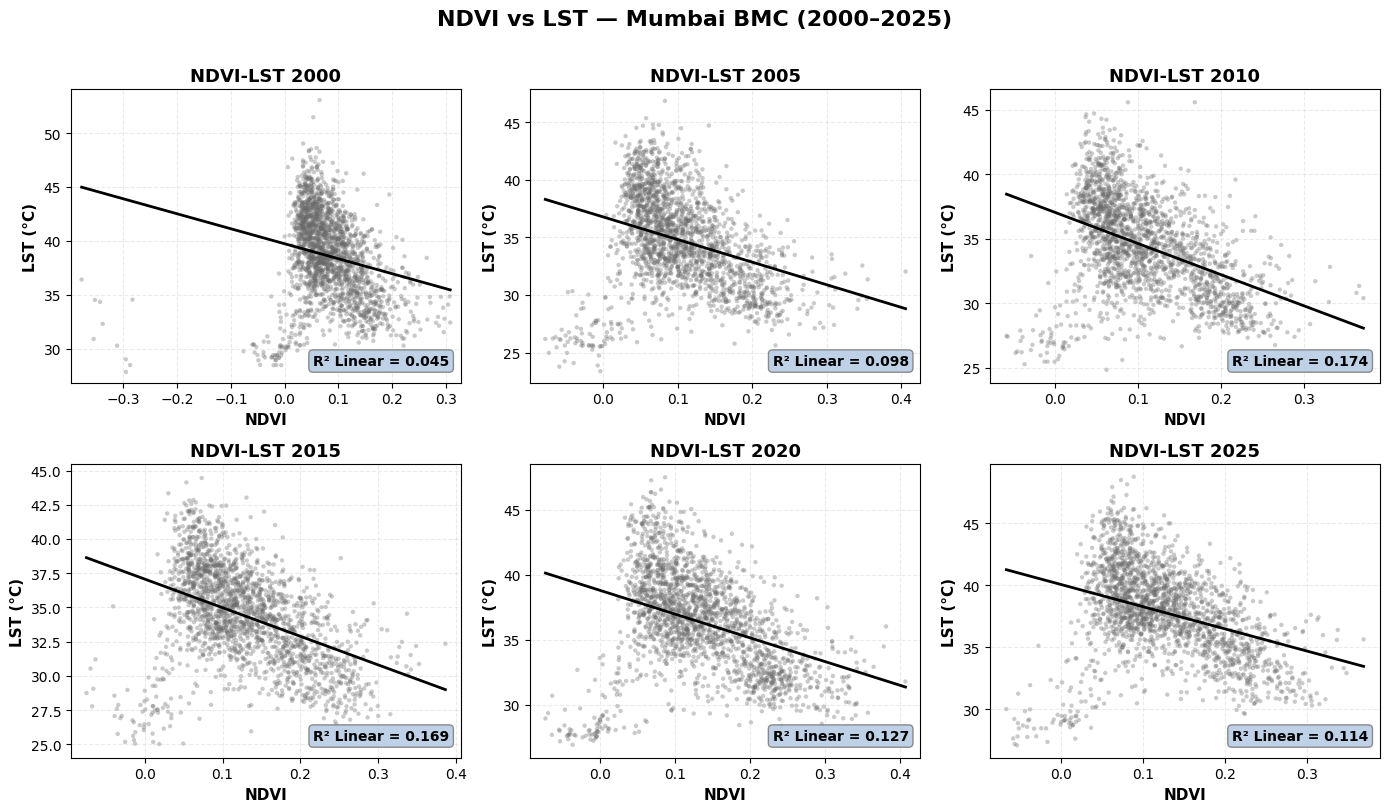

In [ ]:
# =============================================
# GRAPH A — NDVI vs LST — All 6 Years
# 2 rows x 3 columns
# =============================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

fig.suptitle('NDVI vs LST — Mumbai BMC (2000–2025)',
             fontsize=16, fontweight='bold', y=1.01)

for i, year in enumerate(years):
    df_year = data[year]

    ndvi_col = get_col(df_year, 'NDVI')
    lst_col  = get_col(df_year, 'LST')

    ndvi = df_year[ndvi_col].values.astype(float)
    lst  = df_year[lst_col].values.astype(float)

    ndvi, lst = clean_data(ndvi, lst)

    # Linear regression
    slope, intercept, r, p, _ = stats.linregress(ndvi, lst)
    x_line = np.linspace(ndvi.min(), ndvi.max(), 100)
    r2 = r**2

    # Plot scatter
    axes[i].scatter(ndvi, lst,
                   color='dimgray',
                   alpha=0.35, s=10,
                   edgecolors='none')

    # Plot regression line
    axes[i].plot(x_line, slope*x_line + intercept,
                'k-', linewidth=2)

    # R² label — blue box like reference paper
    axes[i].text(0.97, 0.05,
                f'R² Linear = {r2:.3f}',
                transform=axes[i].transAxes,
                ha='right', va='bottom',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round',
                         facecolor='#b8cce4',
                         edgecolor='gray',
                         alpha=0.9))

    axes[i].set_title(f'NDVI-LST {year}',
                     fontsize=13, fontweight='bold')
    axes[i].set_xlabel('NDVI', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('LST (°C)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.25, linestyle='--')
    axes[i].set_xlim(ndvi.min()-0.02, ndvi.max()+0.02)
    axes[i].set_ylim(lst.min()-1, lst.max()+1)

    print(f'{year} NDVI-LST: r={r:.3f} | R²={r2:.3f} | p={p:.4f}')

plt.tight_layout()
plt.savefig('GraphA_NDVI_vs_LST_AllYears.png',
            dpi=300, bbox_inches='tight')
plt.show()



2000 NDBI-LST: r=0.614 | R²=0.377 | p=0.0000
2005 NDBI-LST: r=0.707 | R²=0.500 | p=0.0000
2010 NDBI-LST: r=0.733 | R²=0.537 | p=0.0000
2015 NDBI-LST: r=0.659 | R²=0.434 | p=0.0000
2020 NDBI-LST: r=0.664 | R²=0.441 | p=0.0000
2025 NDBI-LST: r=0.680 | R²=0.462 | p=0.0000


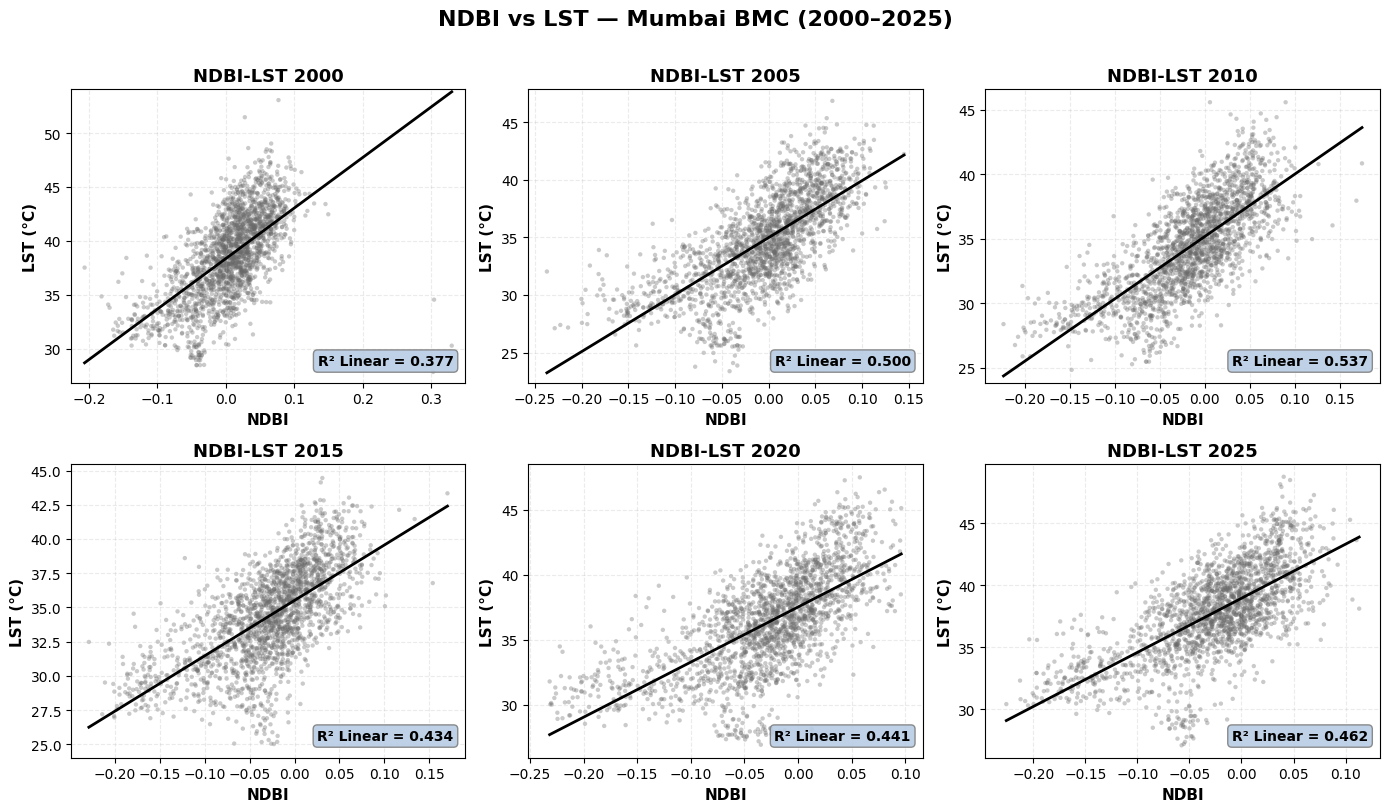


Graph B saved — NDBI vs LST all years!


In [ ]:
# =============================================
# GRAPH B — NDBI vs LST — All 6 Years
# 2 rows x 3 columns
# =============================================

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

fig.suptitle('NDBI vs LST — Mumbai BMC (2000–2025)',
             fontsize=16, fontweight='bold', y=1.01)

for i, year in enumerate(years):
    df_year = data[year]

    ndbi_col = get_col(df_year, 'NDBI')
    lst_col  = get_col(df_year, 'LST')

    ndbi = df_year[ndbi_col].values.astype(float)
    lst  = df_year[lst_col].values.astype(float)

    ndbi, lst = clean_data(ndbi, lst)

    slope, intercept, r, p, _ = stats.linregress(ndbi, lst)
    x_line = np.linspace(ndbi.min(), ndbi.max(), 100)
    r2 = r**2

    axes[i].scatter(ndbi, lst,
                   color='dimgray',
                   alpha=0.35, s=10,
                   edgecolors='none')

    axes[i].plot(x_line, slope*x_line + intercept,
                'k-', linewidth=2)

    axes[i].text(0.97, 0.05,
                f'R² Linear = {r2:.3f}',
                transform=axes[i].transAxes,
                ha='right', va='bottom',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round',
                         facecolor='#b8cce4',
                         edgecolor='gray',
                         alpha=0.9))

    axes[i].set_title(f'NDBI-LST {year}',
                     fontsize=13, fontweight='bold')
    axes[i].set_xlabel('NDBI', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('LST (°C)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.25, linestyle='--')
    axes[i].set_xlim(ndbi.min()-0.02, ndbi.max()+0.02)
    axes[i].set_ylim(lst.min()-1, lst.max()+1)

    print(f'{year} NDBI-LST: r={r:.3f} | R²={r2:.3f} | p={p:.4f}')

plt.tight_layout()
plt.savefig('GraphB_NDBI_vs_LST_AllYears.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("\nGraph B saved — NDBI vs LST all years!")


2000 NDWI-LST: r=0.052 | R²=0.003 | p=0.0192
2005 NDWI-LST: r=0.138 | R²=0.019 | p=0.0000
2010 NDWI-LST: r=0.281 | R²=0.079 | p=0.0000
2015 NDWI-LST: r=0.288 | R²=0.083 | p=0.0000
2020 NDWI-LST: r=0.210 | R²=0.044 | p=0.0000
2025 NDWI-LST: r=0.188 | R²=0.035 | p=0.0000


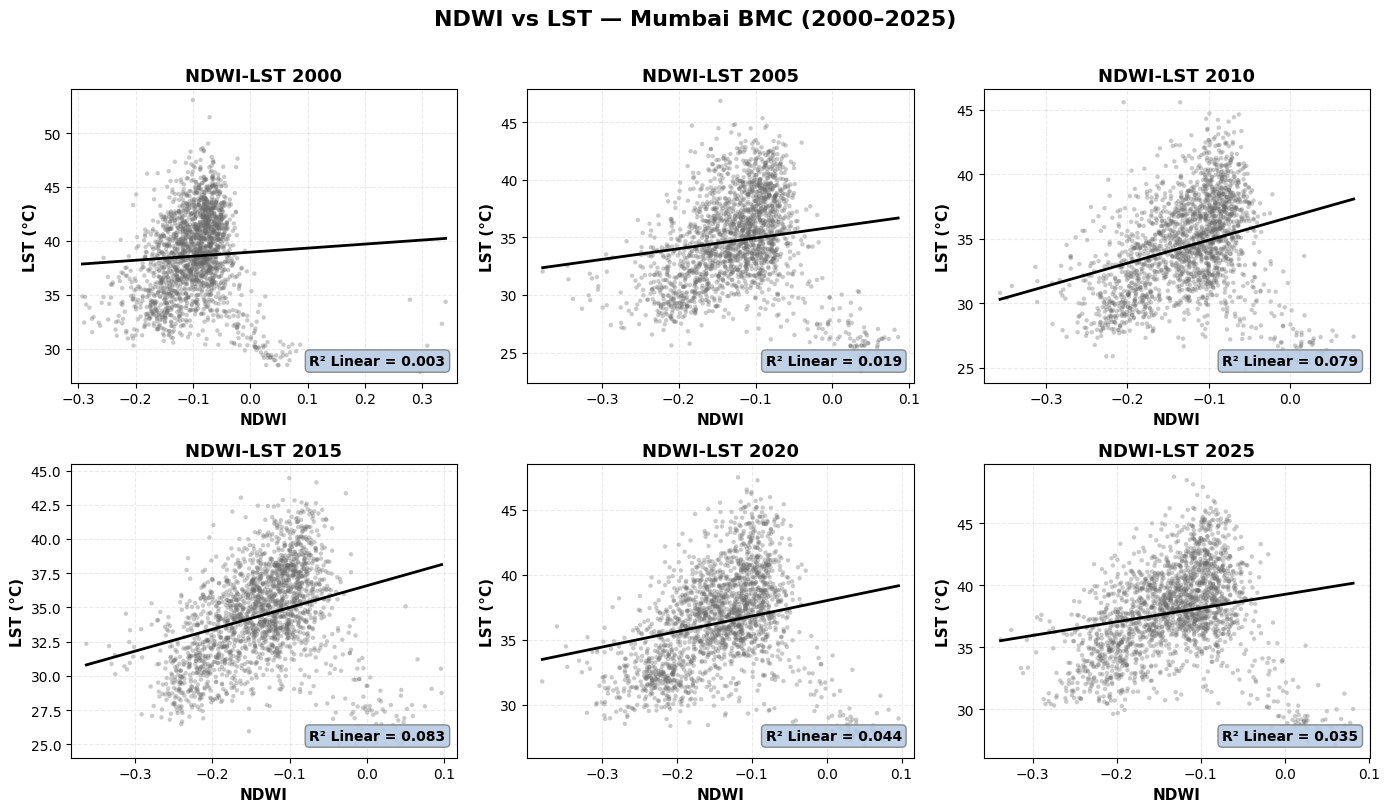

In [ ]:
# =============================================
# GRAPH C — NDWI vs LST — All 6 Years
# 2 rows x 3 columns
# =============================================

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

fig.suptitle('NDWI vs LST — Mumbai BMC (2000–2025)',
             fontsize=16, fontweight='bold', y=1.01)

for i, year in enumerate(years):
    df_year = data[year]

    ndwi_col = get_col(df_year, 'NDWI')
    lst_col  = get_col(df_year, 'LST')

    ndwi = df_year[ndwi_col].values.astype(float)
    lst  = df_year[lst_col].values.astype(float)

    ndwi, lst = clean_data(ndwi, lst)

    slope, intercept, r, p, _ = stats.linregress(ndwi, lst)
    x_line = np.linspace(ndwi.min(), ndwi.max(), 100)
    r2 = r**2

    axes[i].scatter(ndwi, lst,
                   color='dimgray',
                   alpha=0.35, s=10,
                   edgecolors='none')

    axes[i].plot(x_line, slope*x_line + intercept,
                'k-', linewidth=2)

    axes[i].text(0.97, 0.05,
                f'R² Linear = {r2:.3f}',
                transform=axes[i].transAxes,
                ha='right', va='bottom',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round',
                         facecolor='#b8cce4',
                         edgecolor='gray',
                         alpha=0.9))

    axes[i].set_title(f'NDWI-LST {year}',
                     fontsize=13, fontweight='bold')
    axes[i].set_xlabel('NDWI', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('LST (°C)', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.25, linestyle='--')
    axes[i].set_xlim(ndwi.min()-0.02, ndwi.max()+0.02)
    axes[i].set_ylim(lst.min()-1, lst.max()+1)

    print(f'{year} NDWI-LST: r={r:.3f} | R²={r2:.3f} | p={p:.4f}')

plt.tight_layout()
plt.savefig('GraphC_NDWI_vs_LST_AllYears.png',
            dpi=300, bbox_inches='tight')
plt.show()